# Decimation Sweep — Results Analysis

Analyse the CSV produced by the no-bandpass decimation sweep
(`configs/frequency_decoding_sweep_no_bandpass_decimate.yaml`).

- **Section 1** — Data loading & setting labels
- **Section 2** — Above-chance detection per session and setting
- **Section 3** — Cross-setting comparison (box-and-whisker plot)
- **Section 4** — Paired statistical tests between settings

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from pathlib import Path
from scipy.stats import wilcoxon

plt.style.use('academic.mplstyle')

## 1  Data Loading & Setting Labels

In [2]:
CSV_PATH = Path("/home/mila/s/sobralm/auditorydecoding/results/decimate_sweep_2.csv")
df = pd.read_csv(CSV_PATH)

METRIC = "balanced_accuracy"
ALPHA = 0.05

print(f"Total rows:  {len(df)}")
print(f"Recordings:  {df['recording_id'].nunique()}")
df.head()

Total rows:  312
Recordings:  39


,run_name,recording_id,lowcut,highcut,stft,decimate_factor,accuracy,balanced_accuracy,f1_macro,cohen_kappa,perm_pvalue,perm_zscore,n_classes,n_valid_samples,elapsed_seconds
0,lonone_hinone_stft_dec5,sub-02_ses-01_task-AcousStim_acq-RH_desc-raw,NaN,NaN,True,5,0.456140,0.407926,0.397227,0.351262,0.0,8.028871,7,114,21.06
1,lonone_hinone_stft_dec10,sub-02_ses-01_task-AcousStim_acq-RH_desc-raw,NaN,NaN,True,10,0.438596,0.410097,0.413071,0.332724,0.0,8.013072,7,114,23.20
2,lonone_hinone_stft_dec10,sub-02_ses-01_task-AcousStim_acq-LH_desc-raw,NaN,NaN,True,10,0.433333,0.381099,0.382330,0.313131,0.0,7.688846,7,120,24.14
3,lonone_hinone_stft_dec2,sub-02_ses-01_task-AcousStim_acq-LH_desc-raw,NaN,NaN,True,2,0.516667,0.501705,0.506193,0.416009,0.0,11.415836,7,120,24.89
4,lonone_hinone_raw_dec10,sub-02_ses-01_task-AcousStim_acq-LH_desc-raw,NaN,NaN,False,10,0.358333,0.313322,0.310800,0.225417,0.0,5.475661,7,120,24.46


In [3]:
def setting_label(row: pd.Series) -> str:
    feat = "STFT" if row["stft"] else "Raw"
    dec = int(row["decimate_factor"])
    resample = f"dec{dec}" if dec > 1 else "nodec"
    return f"{feat}, {resample}"

df["setting"] = df.apply(setting_label, axis=1)

eegnet_dir = Path("/home/mila/s/sobralm/Foundry/runs/EEGNET_NEUROSOFT_ALL_SESSIONS")
eegnet_frames = []
for session_dir in sorted(eegnet_dir.iterdir()):
    csv_path = session_dir / "results.csv"
    if csv_path.exists():
        eegnet_frames.append(pd.read_csv(csv_path))
df_eegnet = pd.concat(eegnet_frames, ignore_index=True)
df_eegnet["setting"] = "EEGNet"
df = pd.concat([df, df_eegnet], ignore_index=True)

SETTING_ORDER = [
    "Raw, nodec",
    "Raw, dec2",
    "Raw, dec5",
    "Raw, dec10",
    "STFT, nodec",
    "STFT, dec2",
    "STFT, dec5",
    "STFT, dec10",
    "EEGNet",
]

PALETTE = {
    "Raw, nodec":  "#a8d0e6",
    "Raw, dec2":   "#6b9ac4",
    "Raw, dec5":   "#3a6ea5",
    "Raw, dec10":  "#003f5c",
    "STFT, nodec": "#f4a6c1",
    "STFT, dec2":  "#e8759b",
    "STFT, dec5":  "#d45087",
    "STFT, dec10": "#a03060",
    "EEGNet":      "#6abf69",
}

print("Settings:", df["setting"].unique())
print(f"Total rows: {len(df)}")
print(f"EEGNet sessions: {len(df_eegnet)}")

Settings: <StringArray>
[ 'STFT, dec5', 'STFT, dec10',  'STFT, dec2',  'Raw, dec10',   'Raw, dec5',
  'Raw, nodec',   'Raw, dec2', 'STFT, nodec',      'EEGNet']
Length: 9, dtype: str
Total rows: 351
EEGNet sessions: 39


## 2  Above-Chance Detection

A session/setting pair is **above chance** when the permutation
p-value < 0.05.

In [4]:
df["above_chance"] = df["perm_pvalue"] < ALPHA

pivot_above = df.pivot_table(
    index="recording_id",
    columns="setting",
    values="above_chance",
    aggfunc="first",
)[SETTING_ORDER]

pivot_acc = df.pivot_table(
    index="recording_id",
    columns="setting",
    values=METRIC,
    aggfunc="first",
)[SETTING_ORDER]

n_above = pivot_above.sum()
n_total = len(pivot_above)

print("Sessions above chance (p < 0.05) per setting:")
for s in SETTING_ORDER:
    print(f"  {s:25s}  {int(n_above[s]):2d} / {n_total}")

Sessions above chance (p < 0.05) per setting:
  Raw, nodec                 36 / 39
  Raw, dec2                  36 / 39
  Raw, dec5                  36 / 39
  Raw, dec10                 36 / 39
  STFT, nodec                35 / 39
  STFT, dec2                 36 / 39
  STFT, dec5                 38 / 39
  STFT, dec10                38 / 39
  EEGNet                     39 / 39


In [5]:
ABOVE_STYLE = "background-color: #dceef7; color: #003f5c"
BELOW_STYLE = "background-color: #f5dde5; color: #a03060"

styled = pivot_acc.style.apply(
    lambda col: [
        ABOVE_STYLE if pivot_above.loc[idx, col.name] else BELOW_STYLE
        for idx in col.index
    ],
    axis=0,
).format("{:.4f}")

styled

setting,"Raw, nodec","Raw, dec2","Raw, dec5","Raw, dec10","STFT, nodec","STFT, dec2","STFT, dec5","STFT, dec10",EEGNet
recording_id,,,,,,,,,
sub-01_ses-01_task-AcousStim_acq-LH_desc-raw,0.1720,0.1711,0.1503,0.1421,0.3251,0.1966,0.2096,0.2258,0.4382
sub-01_ses-02_task-AcousStim_acq-LH_desc-raw,0.0835,0.0898,0.0850,0.0396,0.4035,0.3469,0.1119,0.0923,0.2960
sub-02_ses-01_task-AcousStim_acq-LH_desc-raw,0.2946,0.3122,0.3087,0.3133,0.3692,0.5017,0.4140,0.3811,0.4441
sub-02_ses-01_task-AcousStim_acq-RH_desc-raw,0.2841,0.3044,0.2825,0.2944,0.4392,0.4198,0.4079,0.4101,0.4344
sub-02_ses-02_task-AcousStim_acq-LH_desc-raw,0.2384,0.2384,0.2711,0.2649,0.2488,0.3051,0.2378,0.2501,0.3243
sub-02_ses-02_task-AcousStim_acq-RH_desc-raw,0.1790,0.1510,0.1619,0.1795,0.3586,0.2999,0.2715,0.2623,0.3296
sub-03_ses-01_task-AcousStim_acq-LH_desc-raw,0.5249,0.5133,0.5020,0.4623,0.4202,0.4086,0.4184,0.4341,0.6657
sub-03_ses-01_task-AcousStim_acq-RH_desc-raw,0.4169,0.4203,0.4130,0.4046,0.3624,0.4056,0.4613,0.4719,0.4779
sub-03_ses-03_task-AcousStim_acq-LHanest_desc-raw,0.5052,0.5203,0.5193,0.5245,0.2632,0.2685,0.2908,0.2763,0.5599


## 3  Cross-Setting Comparison — Box-and-Whisker Plot

Each dot is one recording session. The dashed line marks the
median chance level across sessions (1 / n_classes).

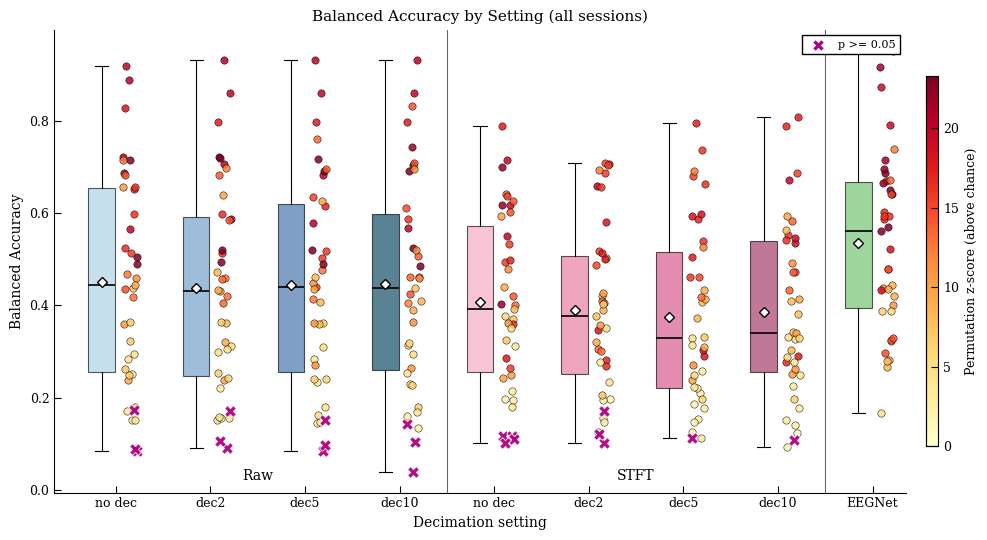

In [6]:
from matplotlib.colors import Normalize
import matplotlib.cm as cm

setting_to_idx = {s: i for i, s in enumerate(SETTING_ORDER)}
BOX_OFFSET = -0.15
STRIP_OFFSET = 0.15

fig, ax = plt.subplots(figsize=(11, 5.5))

positions = [i + BOX_OFFSET for i in range(len(SETTING_ORDER))]
box_data = [df.loc[df["setting"] == s, METRIC].values for s in SETTING_ORDER]
bp = ax.boxplot(
    box_data,
    positions=positions,
    widths=0.28,
    patch_artist=True,
    showfliers=False,
    showmeans=True,
    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=5),
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=0.8),
    capprops=dict(color="black", linewidth=0.8),
)
for patch, setting in zip(bp["boxes"], SETTING_ORDER):
    patch.set_facecolor(PALETTE[setting])
    patch.set_edgecolor("black")
    patch.set_linewidth(0.8)
    patch.set_alpha(0.65)

zscore_col = "perm_zscore"
above_mask = df["perm_pvalue"] < ALPHA
vmax = df.loc[above_mask, zscore_col].quantile(0.95) if above_mask.any() else 10
norm = Normalize(vmin=0, vmax=vmax, clip=True)
cmap = cm.YlOrRd

rng = np.random.default_rng(42)
for _, row in df.iterrows():
    xi = setting_to_idx[row["setting"]] + STRIP_OFFSET
    jitter = rng.uniform(-0.08, 0.08)
    y = row[METRIC]

    if row["perm_pvalue"] < ALPHA:
        color = cmap(norm(row[zscore_col]))
        ax.scatter(
            xi + jitter,
            y,
            s=28,
            c=[color],
            edgecolors="black",
            linewidths=0.4,
            alpha=0.85,
            zorder=3,
        )
    else:
        # Non-significant points are emphasized as magenta X markers.
        ax.scatter(
            xi + jitter,
            y,
            s=70,
            marker="X",
            c="#b1007f",
            edgecolors="white",
            linewidths=0.6,
            alpha=0.95,
            zorder=4,
        )

# Legend handle for the emphasized non-significant points.
ax.scatter([], [], s=70, marker="X", c="#b1007f", edgecolors="white", linewidths=0.6, label="p >= 0.05")

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=30, shrink=0.8)
cbar.set_label("Permutation z-score (above chance)", fontsize=9)


dec_labels = ["no dec", "dec2", "dec5", "dec10", "no dec", "dec2", "dec5", "dec10", "EEGNet"]
ax.set_xticks(range(len(SETTING_ORDER)))
ax.set_xticklabels(dec_labels)
ax.axvline(3.5, color="black", linewidth=0.8, alpha=0.6)
ax.axvline(7.5, color="black", linewidth=0.8, alpha=0.6)
ax.text(1.5, 0.05, "Raw", ha="center", va="top", transform=ax.get_xaxis_transform(), fontsize=10)
ax.text(5.5, 0.05, "STFT", ha="center", va="top", transform=ax.get_xaxis_transform(), fontsize=10)

ax.set_xlabel("Decimation setting")
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Balanced Accuracy by Setting (all sessions)")
ax.legend(loc="upper right", fontsize=8)
sns.despine()

fig.subplots_adjust(bottom=0.26)
plt.tight_layout()
plt.show()
# Save the figure in high resolution
fig.savefig("decimate_balanced_accuracy_by_setting.png", dpi=300, bbox_inches="tight")

## 3b  No-Decimate Comparison — Raw vs STFT vs EEGNet

Simplified box-and-whisker comparing only the three baseline
(no decimation) approaches.

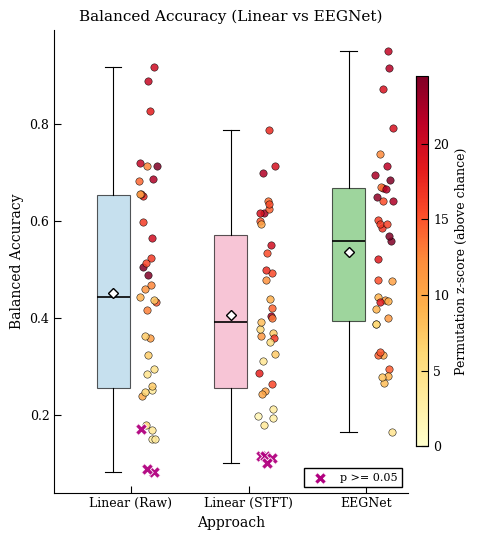

In [12]:
NODEC_ORDER = ["Raw, nodec", "STFT, nodec", "EEGNet"]
NODEC_LABELS = ["Linear (Raw)", "Linear (STFT)", "EEGNet"]

setting_to_idx_nd = {s: i for i, s in enumerate(NODEC_ORDER)}
BOX_OFFSET_ND = -0.15
STRIP_OFFSET_ND = 0.15

df_nodec = df[df["setting"].isin(NODEC_ORDER)]

fig, ax = plt.subplots(figsize=(5, 5.5))

positions_nd = [i + BOX_OFFSET_ND for i in range(len(NODEC_ORDER))]
box_data_nd = [df_nodec.loc[df_nodec["setting"] == s, METRIC].values for s in NODEC_ORDER]
bp = ax.boxplot(
    box_data_nd,
    positions=positions_nd,
    widths=0.28,
    patch_artist=True,
    showfliers=False,
    showmeans=True,
    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=5),
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=0.8),
    capprops=dict(color="black", linewidth=0.8),
)
for patch, setting in zip(bp["boxes"], NODEC_ORDER):
    patch.set_facecolor(PALETTE[setting])
    patch.set_edgecolor("black")
    patch.set_linewidth(0.8)
    patch.set_alpha(0.65)

zscore_col = "perm_zscore"
above_mask_nd = df_nodec["perm_pvalue"] < ALPHA
vmax_nd = df_nodec.loc[above_mask_nd, zscore_col].quantile(0.95) if above_mask_nd.any() else 10
norm_nd = Normalize(vmin=0, vmax=vmax_nd, clip=True)
cmap_nd = cm.YlOrRd

rng = np.random.default_rng(42)
for _, row in df_nodec.iterrows():
    xi = setting_to_idx_nd[row["setting"]] + STRIP_OFFSET_ND
    jitter = rng.uniform(-0.08, 0.08)
    y = row[METRIC]

    if row["perm_pvalue"] < ALPHA:
        color = cmap_nd(norm_nd(row[zscore_col]))
        ax.scatter(
            xi + jitter, y, s=28, c=[color],
            edgecolors="black", linewidths=0.4, alpha=0.85, zorder=3,
        )
    else:
        ax.scatter(
            xi + jitter, y, s=70, marker="X", c="#b1007f",
            edgecolors="white", linewidths=0.6, alpha=0.95, zorder=4,
        )

ax.scatter([], [], s=70, marker="X", c="#b1007f", edgecolors="white", linewidths=0.6, label="p >= 0.05")

sm = cm.ScalarMappable(cmap=cmap_nd, norm=norm_nd)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=30, shrink=0.8)
cbar.set_label("Permutation z-score (above chance)", fontsize=9)

ax.set_xticks(range(len(NODEC_ORDER)))
ax.set_xticklabels(NODEC_LABELS)
ax.set_xlabel("Approach")
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Balanced Accuracy (Linear vs EEGNet)")
ax.legend(loc="lower right", fontsize=8)
sns.despine()

fig.subplots_adjust(bottom=0.26)
plt.tight_layout()
plt.show()
fig.savefig("nodec_balanced_accuracy_comparison.png", dpi=300, bbox_inches="tight")

## 4  Paired Statistical Tests

Wilcoxon signed-rank test for every pair of settings,
matched by recording.

In [8]:
rows = []
for a, b in combinations(SETTING_ORDER, 2):
    vals_a = pivot_acc[a].values
    vals_b = pivot_acc[b].values
    diff = vals_b - vals_a
    stat, p = wilcoxon(diff)
    rows.append({
        "Setting A": a,
        "Setting B": b,
        "median(A)": f"{np.median(vals_a):.4f}",
        "median(B)": f"{np.median(vals_b):.4f}",
        "median(B-A)": f"{np.median(diff):+.4f}",
        "B wins": int((diff > 0).sum()),
        "A wins": int((diff < 0).sum()),
        "Ties": int((diff == 0).sum()),
        "Wilcoxon p": f"{p:.4g}",
    })

results_df = pd.DataFrame(rows)
results_df

,Setting A,Setting B,median(A),median(B),median(B-A),B wins,A wins,Ties,Wilcoxon p
0,"Raw, nodec","Raw, dec2",0.4428,0.4313,+0.0000,18,19,2,0.3857
1,"Raw, nodec","Raw, dec5",0.4428,0.4400,+0.0015,21,18,0,0.9505
2,"Raw, nodec","Raw, dec10",0.4428,0.4383,+0.0005,20,19,0,0.9285
3,"Raw, nodec","STFT, nodec",0.4428,0.3911,-0.0542,15,24,0,0.124
4,"Raw, nodec","STFT, dec2",0.4428,0.3757,-0.0671,14,25,0,0.02888
5,"Raw, nodec","STFT, dec5",0.4428,0.3290,-0.0381,14,25,0,0.008562
6,"Raw, nodec","STFT, dec10",0.4428,0.3393,-0.0561,14,25,0,0.005696
7,"Raw, nodec",EEGNet,0.4428,0.5599,+0.0813,32,7,0,5.758e-06
8,"Raw, dec2","Raw, dec5",0.4313,0.4400,-0.0022,15,21,3,0.33
9,"Raw, dec2","Raw, dec10",0.4313,0.4383,+0.0011,20,16,3,0.2854
